In [1]:
# PACKAGES
## data manipulation
import pandas as pd
import numpy as np

## confidence interval
import math

## hypothesis test
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## data viz
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# PATHS AND METHODS

## My min max scaler
def my_scaler(x_unscaled, x_min=None, x_max=None):
    if x_min == None:
        x_min=x_unscaled.min()
    if x_max == None:
        x_max=x_unscaled.max()
    x_scaled = (x_unscaled - x_min)/(x_max - x_min)
    return x_scaled

## confidence interval 95%
def my_ci_95(stats, r=2):
    
    ci95_hi = []
    ci95_lo = []
    alpha = []

    for i in stats.index:
        m, c, s = stats.loc[i]
        a = 1.96*s/math.sqrt(c)
        ci95_hi.append(m + a)
        ci95_lo.append(m - a)
        alpha.append(a)

    stats['ci95_lo'] = ci95_lo
    stats['ci95_hi'] = ci95_hi
    stats['alpha'] = alpha

    stats['mean'] = round(stats['mean'], r)
    stats['alpha'] = round(stats['alpha'], r)

    return(stats.reset_index())

In [3]:
# DEFINING EXPERIMENT PARAMETERS
## seed list
seed_list = [428956419, 1954324947, 1145661099, 1835732737, 794161987, 1329531353, 200496737, 633816299, 1410143363, 1282538739]
## scenarion list
scenario_list = ['sample']
## algorithms list
algo_list = ['tetris', 'thea', 'edf', 'mcf', 'edfmcf']

In [4]:
# IMPORT DATASETS

# dataframes
total_seed_server = pd.DataFrame()
total_seed_user = pd.DataFrame()
total_seed_service = pd.DataFrame()
# object to count the quantity of experiments
n_exp = 0

# loop to get results
for algo_name in algo_list:

    for scenario in scenario_list:

        ## count experiment
        n_exp = n_exp + 1

        for seed_value in seed_list:

            # server
            ## getting results by seeds
            each_seed_server = pd.read_csv(f"results/{algo_name}_logsserver_{scenario}_{seed_value}.csv")
            each_seed_server['seed'] = seed_value
            each_seed_server['scenario'] = scenario
            each_seed_server['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_server = pd.concat([total_seed_server, each_seed_server])
            total_seed_server = total_seed_server.reset_index(drop=True)

            # user
            ## getting results by seeds
            each_seed_user = pd.read_csv(f"results/{algo_name}_logsuser_{scenario}_{seed_value}.csv")
            each_seed_user['seed'] = seed_value
            each_seed_user['scenario'] = scenario
            each_seed_user['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_user = pd.concat([total_seed_user, each_seed_user])
            total_seed_user = total_seed_user.reset_index(drop=True)

            # service
            ## getting results by seeds
            each_seed_service = pd.read_csv(f"results/{algo_name}_logsservice_{scenario}_{seed_value}.csv")
            each_seed_service['seed'] = seed_value
            each_seed_service['scenario'] = scenario
            each_seed_service['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_service = pd.concat([total_seed_service, each_seed_service])
            total_seed_service = total_seed_service.reset_index(drop=True)

In [5]:
# FEATURE ENGINEERING

## create new obj to do feature engineering
dt_power = total_seed_server.loc[(total_seed_server['Available'])].reset_index(drop=True).copy()
dt_server = total_seed_server.loc[(total_seed_server['Available']) & (total_seed_server['CPU Demand'] > 0)].reset_index(drop=True).copy()
dt_user = total_seed_user.copy()
dt_service = total_seed_service.copy()

## user dataset
# compute sla violation variable
dt_user['sla_violations'] = 0
dt_user.loc[dt_user['Delay sla deadlines'] < 0, 'sla_violations'] = 1
dt_user['cumulative_sla_violations'] = dt_user.groupby(['algorithm', 'scenario', 'seed'])['sla_violations'].cumsum()

## server dataset
# compute server access
dt_server['server_access'] = 0
dt_server.loc[dt_server['CPU Demand'] > 0, 'server_access'] = 1
dt_server['cumulative_server_access'] = dt_server.groupby(['Instance ID', 'algorithm', 'scenario', 'seed'])['server_access'].cumsum()
dt_total_server_access = dt_server.groupby(['algorithm', 'scenario', 'seed'])['server_access'].sum().reset_index().rename(columns={'server_access':'total_server_access'})
dt_server = dt_server.merge(dt_total_server_access, how='left', on=['algorithm', 'scenario', 'seed'])
dt_total_server_access_avg = dt_server.loc[dt_server['Time Step'] == 60].groupby(by=['algorithm', 'Object', 'scenario'])['total_server_access'].agg(['mean', 'count']).reset_index()
dt_total_server_access_avg['product'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['count']
dt_total_server_access_avg = dt_total_server_access_avg.merge(dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_total_server_access_avg['weight'] = dt_total_server_access_avg['product']/dt_total_server_access_avg['sum']
dt_total_server_access_avg['n_server_access'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['weight']
dt_total_server_access_avg = dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['n_server_access'].agg(['sum']).reset_index().rename(columns={'sum':'n_server_access'})
dt_server_access_avg = dt_server.loc[dt_server['Time Step'] == 60].groupby(by=['algorithm', 'Object', 'scenario'])['cumulative_server_access'].agg(['mean', 'count']).reset_index()
dt_server_access_avg['product'] = dt_server_access_avg['mean']*dt_server_access_avg['count']
dt_server_access_avg = dt_server_access_avg.merge(dt_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['weight'] = dt_server_access_avg['product']/dt_server_access_avg['sum']
dt_server_access_avg = dt_server_access_avg.merge(dt_total_server_access_avg, how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['server_access_by_server'] = dt_server_access_avg['n_server_access']*dt_server_access_avg['weight']

# compute free resources
dt_server['CPU Free'] = dt_server['CPU'] - dt_server['CPU Demand']
dt_server['RAM Free'] = dt_server['RAM'] - dt_server['RAM Demand']
# compute usage metrics
dt_server['CPU Usage'] = (dt_server['CPU Demand'] * 100) / dt_server['CPU']
dt_server['RAM Usage'] = (dt_server['RAM Demand'] * 100) / dt_server['RAM']
dt_server['Servers Usage'] = (dt_server['CPU Usage'] + dt_server['RAM Usage']) / 2

# create new obj withou cloud server
dt_server_edge = dt_server.loc[(dt_server['Instance ID'] != 7)].reset_index(drop=True)

# normalization
## CPU
dt_server_edge.loc[:, 'CPU Free_norm'] = my_scaler(x_unscaled=dt_server_edge.loc[:, 'CPU Free'])
## RAM
dt_server_edge.loc[:, 'RAM Free_norm'] = my_scaler(x_unscaled=dt_server_edge.loc[:, 'RAM Free'])
# compute Resource Imbalance Index (RII)
dt_server_edge['RII'] = dt_server_edge[['CPU Free_norm', 'RAM Free_norm']].std(axis=1)

In [6]:
# RESULTS TO USE ON OVERLEAF PLOTS

## SLA Violations
stats_sla = dt_user.loc[dt_user['Time Step'] == 60].groupby(by=['algorithm', 'scenario'])['cumulative_sla_violations'].agg(['mean', 'count', 'std'])
stats_sla = my_ci_95(stats_sla)
print(">>>>>>>>>>>>>>>>>>>> cumulative_sla_violations <<<<<<<<<<<<<<<<<<<<\n", stats_sla[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Delay
stats_delay = dt_user.groupby(by=['algorithm', 'scenario'])['Delays'].agg(['mean', 'count', 'std'])
stats_delay = my_ci_95(stats_delay)
print(">>>>>>>>>>>>>>>>>>>> Delays <<<<<<<<<<<<<<<<<<<<\n", stats_delay[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Power Consumption
stats_power = dt_power.groupby(by=['algorithm', 'scenario'])['Power Consumption'].agg(['mean', 'count', 'std'])
stats_power = my_ci_95(stats_power)
print(">>>>>>>>>>>>>>>>>>>> Power <<<<<<<<<<<<<<<<<<<<\n", stats_power[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Percent Server Access
stats_access = dt_server_access_avg.groupby(by=['algorithm', 'Object', 'scenario'])['weight'].agg(['mean', 'count', 'std'])
stats_access = my_ci_95(stats_access,  r=2)
stats_access['mean_percent'] = stats_access['mean']*100
print(">>>>>>>>>>>>>>>>>>>> Server Access <<<<<<<<<<<<<<<<<<<<\n", stats_access[['algorithm', 'Object', 'scenario', 'mean_percent']], '\n')

>>>>>>>>>>>>>>>>>>>> cumulative_sla_violations <<<<<<<<<<<<<<<<<<<<
   algorithm scenario   mean  alpha
0       edf   sample  31.40   1.51
1    edfmcf   sample  59.50   0.22
2       mcf   sample  59.75   0.19
3    tetris   sample   0.00   0.00
4      thea   sample   0.00   0.00 

>>>>>>>>>>>>>>>>>>>> Delays <<<<<<<<<<<<<<<<<<<<
   algorithm scenario    mean  alpha
0       edf   sample   81.11   5.31
1    edfmcf   sample  134.24   5.85
2       mcf   sample  133.01   5.93
3    tetris   sample   22.46   0.48
4      thea   sample   25.99   0.35 

>>>>>>>>>>>>>>>>>>>> Power <<<<<<<<<<<<<<<<<<<<
   algorithm scenario    mean  alpha
0       edf   sample  116.40   2.15
1    edfmcf   sample  109.44   2.18
2       mcf   sample  109.49   2.17
3    tetris   sample  123.67   2.36
4      thea   sample  132.29   1.90 

>>>>>>>>>>>>>>>>>>>> Server Access <<<<<<<<<<<<<<<<<<<<
    algorithm        Object scenario  mean_percent
0        edf  EdgeServer_3   sample          11.0
1        edf  EdgeServer_5 

ANOVA: null hypothesis (H₀): All group means are equal
F-statistic: 7173.27
p-value: 0.000000000
Tukey HSD Post-hoc Test: which ones differ significantly?
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   edf edfmcf     28.1   0.0  26.7153  29.4847   True
   edf    mcf    28.35   0.0  26.9653  29.7347   True
   edf tetris    -31.4   0.0 -32.7847 -30.0153   True
   edf   thea    -31.4   0.0 -32.7847 -30.0153   True
edfmcf    mcf     0.25 0.987  -1.1347   1.6347  False
edfmcf tetris    -59.5   0.0 -60.8847 -58.1153   True
edfmcf   thea    -59.5   0.0 -60.8847 -58.1153   True
   mcf tetris   -59.75   0.0 -61.1347 -58.3653   True
   mcf   thea   -59.75   0.0 -61.1347 -58.3653   True
tetris   thea      0.0   1.0  -1.3847   1.3847  False
-----------------------------------------------------


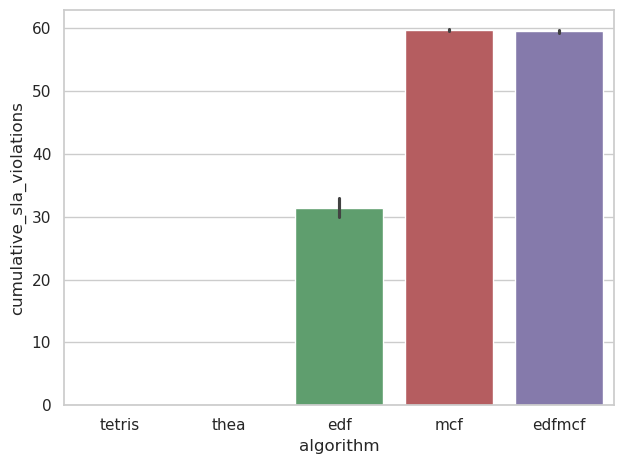

In [7]:
# SLA VIOLATION DATA-VIZ

# Perform one-way ANOVA
dt_user_sla = dt_user.loc[dt_user['Time Step'] == 60].reset_index().copy()
anova_result = stats.f_oneway(*[group["cumulative_sla_violations"].values for name, group in dt_user_sla.groupby("algorithm")])
# Print ANOVA results
# Null hypothesis (H₀): All group means are equal.
# Alternative hypothesis (H₁): At least one group mean is different.
print("ANOVA: null hypothesis (H₀): All group means are equal")
print(f"F-statistic: {anova_result.statistic:.2f}")
print(f"p-value: {anova_result.pvalue:.9f}")
# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=dt_user_sla["cumulative_sla_violations"], groups=dt_user_sla["algorithm"], alpha=0.05)
# Print Tukey HSD results
# Compare all possible pairs of group means to find which ones differ significantly.
print("Tukey HSD Post-hoc Test: which ones differ significantly?")
print(tukey_result)

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.barplot(data=dt_user.loc[dt_user['Time Step'] == 60].reset_index(), x='algorithm', y='cumulative_sla_violations', hue='algorithm', estimator=np.mean, errorbar=('ci', 95))
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()

ANOVA: null hypothesis (H₀): All group means are equal
F-statistic: 588.59
p-value: 0.000000000
Tukey HSD Post-hoc Test: which ones differ significantly?
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   edf edfmcf   53.1318    0.0   44.4281   61.8355   True
   edf    mcf    51.903    0.0   43.1993   60.6067   True
   edf tetris  -58.6479    0.0  -67.3516  -49.9441   True
   edf   thea  -55.1139    0.0  -63.7993  -46.4285   True
edfmcf    mcf   -1.2288 0.9954   -9.9417    7.4841  False
edfmcf tetris -111.7797    0.0 -120.4926 -103.0668   True
edfmcf   thea -108.2457    0.0 -116.9403  -99.5511   True
   mcf tetris -110.5508    0.0 -119.2638 -101.8379   True
   mcf   thea -107.0169    0.0 -115.7115  -98.3223   True
tetris   thea     3.534 0.8019   -5.1606   12.2286  False
---------------------------------------------------------


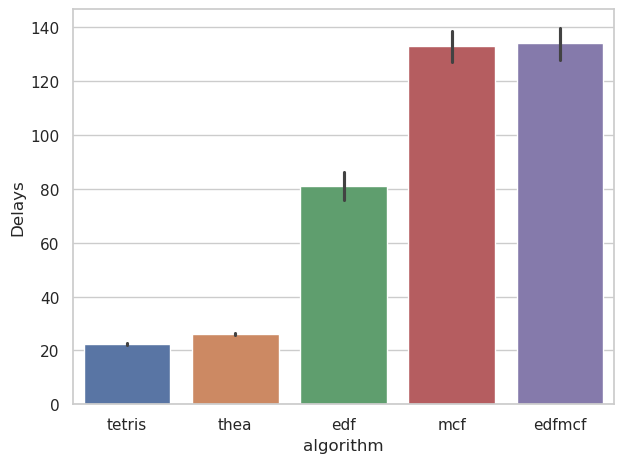

In [8]:
# LATENCY DATA-VIZ

# Perform one-way ANOVA
dt_user_delay = dt_user.dropna(subset=['Delays']).copy()
anova_result = stats.f_oneway(*[group["Delays"].values for name, group in dt_user_delay.groupby("algorithm")])
# Print ANOVA results
# Null hypothesis (H₀): All group means are equal.
# Alternative hypothesis (H₁): At least one group mean is different.
print("ANOVA: null hypothesis (H₀): All group means are equal")
print(f"F-statistic: {anova_result.statistic:.2f}")
print(f"p-value: {anova_result.pvalue:.9f}")
# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=dt_user_delay["Delays"], groups=dt_user_delay["algorithm"], alpha=0.05)
# Print Tukey HSD results
# Compare all possible pairs of group means to find which ones differ significantly.
print("Tukey HSD Post-hoc Test: which ones differ significantly?")
print(tukey_result)

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.barplot(data=dt_user, x='algorithm', y='Delays', hue='algorithm', estimator=np.mean, errorbar=('ci', 95))
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()

ANOVA: null hypothesis (H₀): All group means are equal
F-statistic: 79.27
p-value: 0.000000000
Tukey HSD Post-hoc Test: which ones differ significantly?
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   edf edfmcf  -6.9637 0.0001 -11.2112 -2.7162   True
   edf    mcf  -6.9169 0.0001 -11.1644 -2.6694   True
   edf tetris    7.271    0.0   3.0235 11.5185   True
   edf   thea  15.8838    0.0  11.6362 20.1313   True
edfmcf    mcf   0.0468    1.0  -4.2008  4.2943  False
edfmcf tetris  14.2346    0.0   9.9871 18.4821   True
edfmcf   thea  22.8474    0.0  18.5999 27.0949   True
   mcf tetris  14.1879    0.0   9.9404 18.4354   True
   mcf   thea  22.8007    0.0  18.5532 27.0482   True
tetris   thea   8.6128    0.0   4.3653 12.8603   True
-----------------------------------------------------


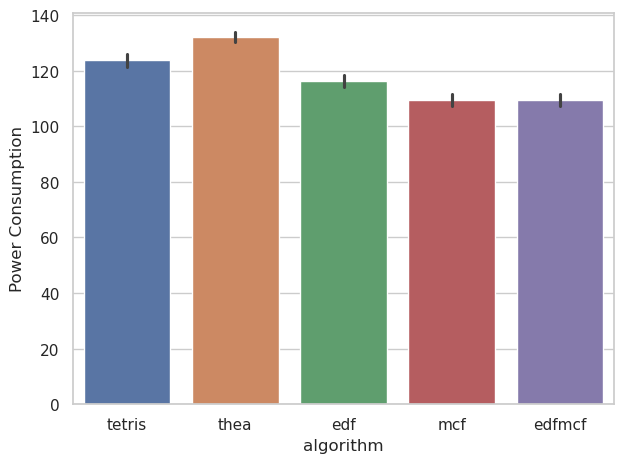

In [9]:
# POWER DATA-VIZ

# Perform one-way ANOVA
dt_server_power = dt_power.copy()
anova_result = stats.f_oneway(*[group["Power Consumption"].values for name, group in dt_server_power.groupby("algorithm")])
# Print ANOVA results
# Null hypothesis (H₀): All group means are equal.
# Alternative hypothesis (H₁): At least one group mean is different.
print("ANOVA: null hypothesis (H₀): All group means are equal")
print(f"F-statistic: {anova_result.statistic:.2f}")
print(f"p-value: {anova_result.pvalue:.9f}")
# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=dt_server_power["Power Consumption"], groups=dt_server_power["algorithm"], alpha=0.05)
# Print Tukey HSD results
# Compare all possible pairs of group means to find which ones differ significantly.
print("Tukey HSD Post-hoc Test: which ones differ significantly?")
print(tukey_result)

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.barplot(data=dt_power, x='algorithm', y='Power Consumption', hue='algorithm', estimator=np.mean, errorbar=('ci', 95))
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()

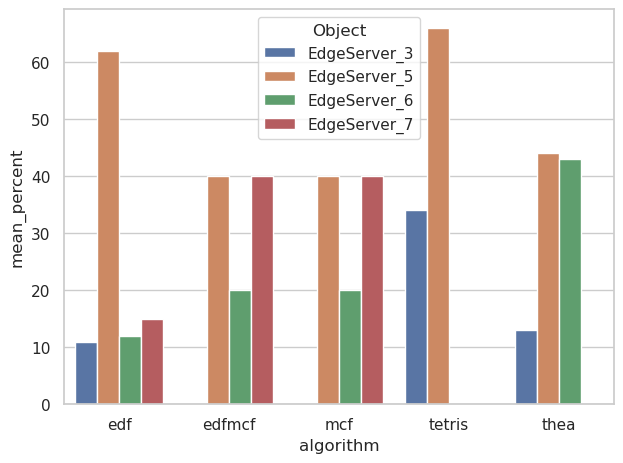

In [10]:
# SERVER ACCESS DATA-VIZ

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.barplot(data=stats_access, x='algorithm', y='mean_percent', hue='Object')
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()